# Exercise 1.1: One- and Two-Compartment Pharmacokinetic Models

In this exercise, we will simulate one-compartment and two-compartment pharmacokinetic models following both single-dose and repeated-dose administration. These models provide a simple mathematical framework for describing drug distribution and elimination within the body.

Use the code below to generate concentration–time profiles and investigate how model structure and parameter choices influence system behavior.

### Questions

1. Compare the concentration–time profiles of the one-compartment and two-compartment models following a single dose. What qualitative differences do you observe?

2. In the two-compartment model, identify the distribution phase and elimination phase. How do the parameters `kcp`, `kpc`, and `ke` affect these dynamics?

3. How do dose size and dosing frequency in the repeated-dose simulations affect drug accumulation and steady-state behavior?

4. Compare how quickly the one-compartment and two-compartment models approach steady-state behavior under repeated dosing. What effect does the presence of a peripheral compartment have on this?

5. Explore the effects of varying the inter-compartmental transfer rates `kcp` and `kpc`. What happens when exchange between compartments becomes very fast or very slow?

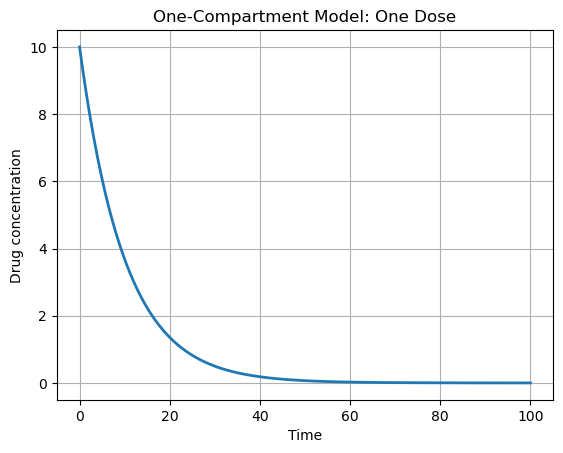

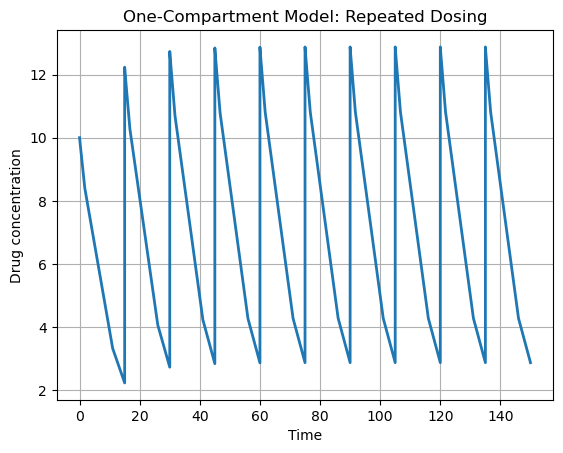

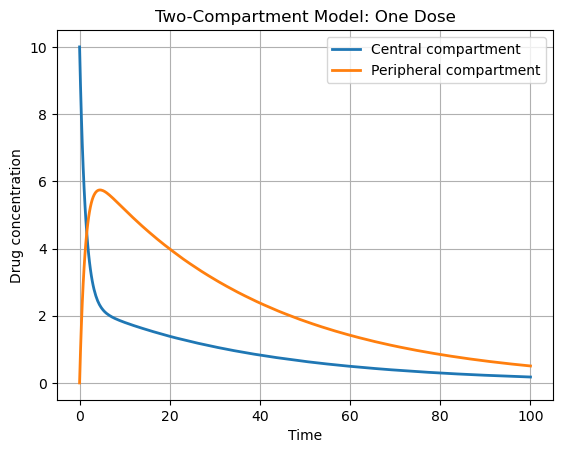

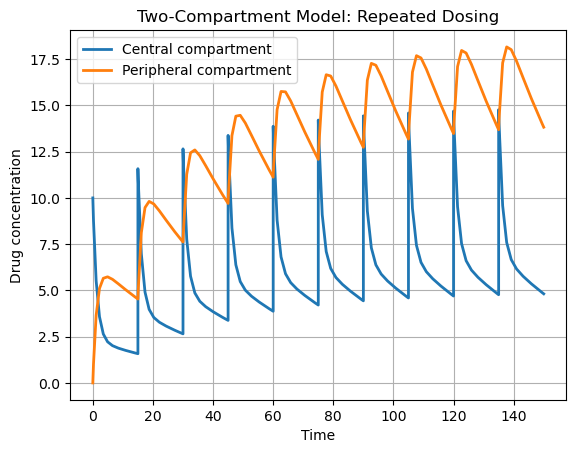

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# One-compartment model: one dose
# ============================================================

ke = 0.1
C0 = [10]
tspan = (0, 100)

def onecomp(t, C):
    return [-ke * C[0]]

sol = solve_ivp(onecomp, tspan, C0, dense_output=True)

t = np.linspace(*tspan, 500)
C = sol.sol(t)[0]

plt.figure()
plt.plot(t, C, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Drug concentration")
plt.title("One-Compartment Model: One Dose")
plt.grid()
plt.show()


# ============================================================
# One-compartment model: repeated dosing
# ============================================================

ke = 0.1
dose = 10
tau = 15
n_doses = 10

t_all = []
C_all = []

C0 = [dose]

for i in range(n_doses):
    t_start = i * tau
    t_end = (i + 1) * tau

    sol = solve_ivp(onecomp, (t_start, t_end), C0)

    t_all.extend(sol.t)
    C_all.extend(sol.y[0])

    C0 = [sol.y[0, -1] + dose]

plt.figure()
plt.plot(t_all, C_all, linewidth=2)
plt.xlabel("Time")
plt.ylabel("Drug concentration")
plt.title("One-Compartment Model: Repeated Dosing")
plt.grid()
plt.show()


# ============================================================
# Two-compartment model: one dose
# ============================================================

kcp = 0.5
kpc = 0.2
ke = 0.1

Cc0 = 10
Cp0 = 0

def twocomp(t, y):
    Cc, Cp = y

    dCc = kpc * Cp - kcp * Cc - ke * Cc
    dCp = kcp * Cc - kpc * Cp

    return [dCc, dCp]

sol = solve_ivp(twocomp, tspan, [Cc0, Cp0], dense_output=True)

t = np.linspace(*tspan, 500)
Cc, Cp = sol.sol(t)

plt.figure()
plt.plot(t, Cc, linewidth=2, label="Central compartment")
plt.plot(t, Cp, linewidth=2, label="Peripheral compartment")
plt.xlabel("Time")
plt.ylabel("Drug concentration")
plt.title("Two-Compartment Model: One Dose")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# Two-compartment model: repeated dosing
# ============================================================

dose = 10
tau = 15
n_doses = 10

t_all = []
Cc_all = []
Cp_all = []

y0 = [dose, 0]

for i in range(n_doses):
    t_start = i * tau
    t_end = (i + 1) * tau

    sol = solve_ivp(twocomp, (t_start, t_end), y0)

    t_all.extend(sol.t)
    Cc_all.extend(sol.y[0])
    Cp_all.extend(sol.y[1])

    y0 = [sol.y[0, -1] + dose, sol.y[1, -1]]

plt.figure()
plt.plot(t_all, Cc_all, linewidth=2, label="Central compartment")
plt.plot(t_all, Cp_all, linewidth=2, label="Peripheral compartment")
plt.xlabel("Time")
plt.ylabel("Drug concentration")
plt.title("Two-Compartment Model: Repeated Dosing")
plt.legend()
plt.grid()
plt.show()

# Exercise 1.2: Noncompartmental Analysis (NCA)

In this exercise, we will simulate concentration–time measurements following a single intravenous dose in a two-compartment pharmacokinetic model. Using only the central compartment concentration measurements, estimate several commonly used noncompartmental pharmacokinetic quantities.

Use the code below to generate the concentration–time data and answer the following questions.

### Questions

1. Estimate the area under the concentration–time curve (AUC) using the trapezoidal rule.

2. Identify the maximum observed concentration (`Cmax`) and the time at which it occurs (`tmax`).

3. Estimate the terminal elimination rate constant `k` by fitting a straight line to the terminal log-concentration data.

4. Use your estimate of `k` to compute the elimination half-life

   $$
   t_{1/2}=\frac{\ln(2)}{k}.
   $$

5. Estimate clearance using

   $$
   CL=\frac{\text{Dose}}{\text{AUC}}.
   $$

6. Estimate the apparent volume of distribution using

   $$
   V_d=\frac{CL}{k}.
   $$

7. Explain why measurements from the central compartment alone may not fully capture drug distribution dynamics in the peripheral compartment.

8. Compare the assumptions underlying NCA with those of mechanistic compartmental models. What information is gained or lost by avoiding an explicit compartmental model?

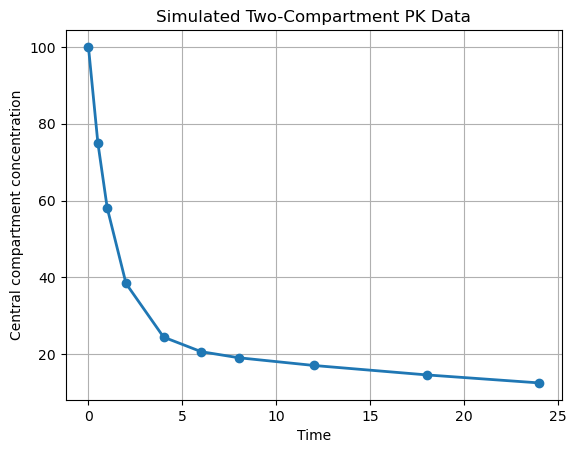

   Time  CentralConcentration
0   0.0            100.000000
1   0.5             75.069867
2   1.0             58.059533
3   2.0             38.416482
4   4.0             24.455955
5   6.0             20.670240
6   8.0             19.086823
7  12.0             17.075975
8  18.0             14.623455
9  24.0             12.534347


In [5]:
import pandas as pd

# Parameters
Dose = 100
kcp = 0.5
kpc = 0.2
ke = 0.1

# Sampling times
t_sample = np.array([0, 0.5, 1, 2, 4, 6, 8, 12, 18, 24])

# Two-compartment IV bolus model
def twocomp(t, y):
    Cc, Cp = y

    dCc = kpc * Cp - kcp * Cc - ke * Cc
    dCp = kcp * Cc - kpc * Cp

    return [dCc, dCp]

# Initial conditions
y0 = [Dose, 0]

# Simulate
sol = solve_ivp(
    twocomp,
    (t_sample[0], t_sample[-1]),
    y0,
    t_eval=t_sample
)

# Central compartment measurements
Cc = sol.y[0]

# Plot measurements
plt.figure()
plt.plot(sol.t, Cc, '-o', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Central compartment concentration")
plt.title("Simulated Two-Compartment PK Data")

plt.grid()
plt.show()

# Display measurements
pk_data = pd.DataFrame({
    "Time": sol.t,
    "CentralConcentration": Cc
})

print(pk_data)

# Exercise 1.3: Hill Coefficients and Receptor Binding

In this exercise, we will investigate how the Hill coefficient influences receptor binding behavior. The Hill equation extends the basic receptor occupancy model by allowing concentration–response relationships that are either more gradual or more switch-like than standard Michaelis–Menten or \(E_{\max}\) kinetics.

Use the code below to generate receptor occupancy curves for different Hill coefficients and answer the following questions.

### Questions

1. Compare the curves for \(n=1\), \(n>1\), and \(n<1\). How does the Hill coefficient affect the steepness of the concentration–response curve?

2. What does the case \(n=1\) represent in relation to the basic receptor occupancy and \(E_{\max}\) models?

3. How do larger Hill coefficients, such as \(n=2\) or \(n=4\), change the transition between low and high receptor occupancy?

4. How do smaller Hill coefficients, such as \(n=0.5\) or \(n=0.25\), change the shape of the concentration–response curve?

5. Based on the simulations, explain why the Hill equation is useful for modeling responses that are more gradual or more switch-like than those predicted by the basic \(E_{\max}\) model.

6. Which Hill coefficient produces the most switch-like response? Which produces the most gradual response? Explain your reasoning using the simulated curves.

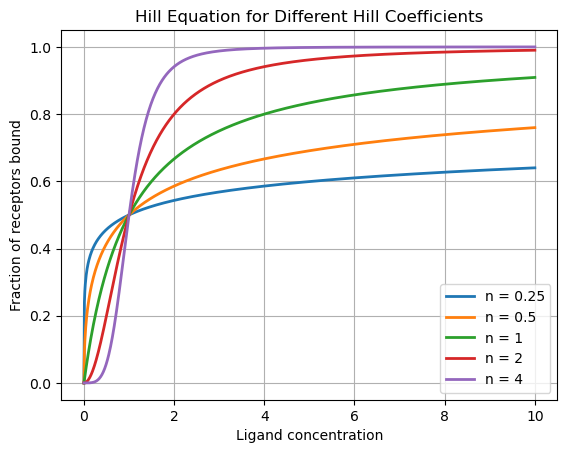

In [6]:

# Ligand concentration range
L = np.linspace(0, 10, 1000)

# Parameters
Kd = 1

# Hill coefficients
n_values = [0.25, 0.5, 1, 2, 4]

plt.figure()

# Plot Hill curves
for n in n_values:
    theta = (L**n) / (Kd**n + L**n)
    plt.plot(L, theta, linewidth=2, label=f'n = {n}')

# Labels and formatting
plt.xlabel('Ligand concentration')
plt.ylabel('Fraction of receptors bound')
plt.title('Hill Equation for Different Hill Coefficients')

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

# Exercise 1.4: Nonlinear Pharmacokinetics and Michaelis–Menten Kinetics

In this exercise, we will investigate nonlinear elimination using the Michaelis–Menten model. This model is useful for describing capacity-limited processes, where elimination increases with concentration at low concentrations but approaches a maximum rate at high concentrations.

Consider the Michaelis–Menten model

$$
v(C)=\frac{V_{\max}C}{K_m+C},
$$

where \(C\) denotes drug concentration.

### Questions

1. Show that when \(C \ll K_m\), the Michaelis–Menten model behaves approximately linearly:

   $$
   v(C)\approx \frac{V_{\max}}{K_m}C.
   $$

2. Show that when \(C \gg K_m\), the metabolic rate approaches saturation:

   $$
   v(C)\approx V_{\max}.
   $$

3. Sketch or simulate the function

   $$
   v(C)=\frac{V_{\max}C}{K_m+C}
   $$

   for several values of \(K_m\) and \(V_{\max}\). How do these parameters affect the shape of the curve?

4. Consider the nonlinear elimination model

   $$
   \frac{dC}{dt}=-\frac{V_{\max}C}{K_m+C}.
   $$

   Compare its qualitative behavior with the linear elimination model

   $$
   \frac{dC}{dt}=-kC.
   $$

   How do the concentration–time profiles differ at high concentrations?  
   *Hint: Use your result from Question 2.*

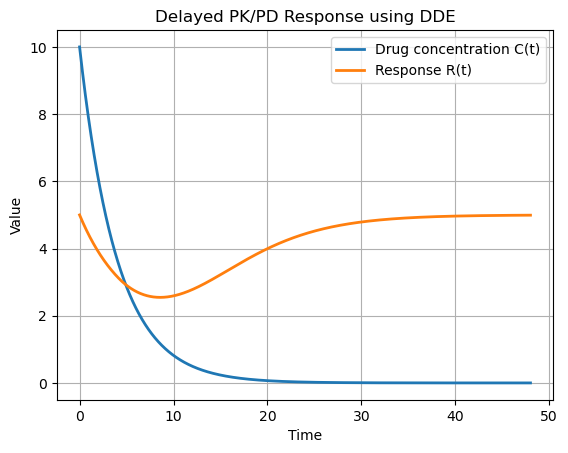

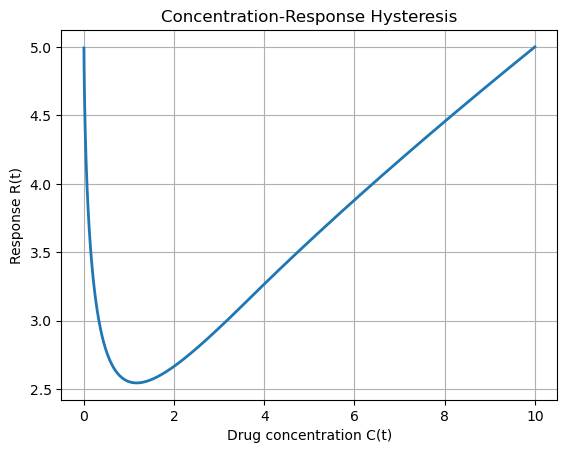

In [7]:
# Parameters
C0 = 10
k = 0.25
kin = 1
kout = 0.2
Emax = 0.8
EC50 = 2
tau = 4

# Time setup
t_end = 48
dt = 0.01
t = np.arange(0, t_end + dt, dt)

# Initialize arrays
C = np.zeros_like(t)
R = np.zeros_like(t)

# History values
C[0] = C0
R[0] = kin / kout

# Helper function for delayed concentration
def get_delayed_C(i):
    delay_steps = int(tau / dt)
    delayed_index = i - delay_steps

    if delayed_index < 0:
        return C0
    else:
        return C[delayed_index]

# Euler simulation
for i in range(1, len(t)):
    C_delay = get_delayed_C(i)

    dCdt = -k * C[i-1]
    dRdt = kin * (1 - Emax * C_delay / (EC50 + C_delay)) - kout * R[i-1]

    C[i] = C[i-1] + dt * dCdt
    R[i] = R[i-1] + dt * dRdt

# Plot concentration and response over time
plt.figure()
plt.plot(t, C, linewidth=2, label='Drug concentration C(t)')
plt.plot(t, R, linewidth=2, label='Response R(t)')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Delayed PK/PD Response using DDE')
plt.legend()
plt.grid(True)
plt.show()

# Plot hysteresis
plt.figure()
plt.plot(C, R, linewidth=2)

plt.xlabel('Drug concentration C(t)')
plt.ylabel('Response R(t)')
plt.title('Concentration-Response Hysteresis')
plt.grid(True)
plt.show()